<a href="https://colab.research.google.com/github/piaseckazaneta/Python/blob/main/Zaneta_Piasecka_Mini_projekt_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. WSTĘP

Cel mini-projektu: Integracja rozproszonych danych relacyjnych NOAA (National Oceanic and Atmospheric Administration) i stworzenie czystego, ujednoliconego zbioru danych (tzw. Master Dataset) o ekstremalnych zjawiskach pogodowych, gotowego do analizy statystycznej i przestrzennej (GIS).

Cel głównego projektu: Odpowiedź na pytanie: "O ile rosną straty finansowe zjawiska w zależności od jego skali fizycznej i czasu trwania?"

Projekt składa się z 2 głównych etapów:
1. Eksploracyjna analiza danych. Podczas EDA zostanie podjęta decyzja, dla którego zjawiska będzie budowany model. Do modelowania zostanie wybrane zjawisko, które generuje największe straty finansowe i dla którego są dostępne w tabeli dodatkowe cechy np. wielkość, skala itp.
2. Budowa modelu regresji liniowej służącego predykcji strat finansowych.

Źródło danych: NOAA.


## 1. IMPORT BIBLIOTEK

In [1]:
import pandas as pd

from google.colab import drive

drive.mount("/content/drive")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. WCZYTANIE DANYCH

Dane pobierane są z dysku google, przez co nie ma potrzeby wczytywania ich przy każdym uruchomieniu kodu.



In [2]:
# Ścieżki do dysku google
storm_events_details = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_details_2025.csv"
storm_events_locations = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_locations_2025.csv"
storm_events_fatalities = "/content/drive/MyDrive/Projekt_Python_2026/StormEvents_fatalities_2025.csv"

# Wczytanie danych
df_details = pd.read_csv(storm_events_details)
df_locations = pd.read_csv(storm_events_locations)
df_fatalities = pd.read_csv(storm_events_fatalities)


## 3. EKSPLORACYJNA ANALIZA DANYCH

### 3.1. Kontrola struktury danych

In [3]:
pd.set_option('display.max_columns', None)

# Sprawdzam 5 pierwszych wierszy tabeli
df_details.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,202503,31,1104,202503,31,1106,201366,1252415,GEORGIA,13,2025,March,Thunderstorm Wind,C,45,CARROLL,FFC,31-MAR-25 11:04:00,EST-5,31-MAR-25 11:06:00,0,0,0,0,1.00K,NaN,Emergency Manager,52.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.22,W,TYUS,2.22,W,TYUS,33.4757,-85.238,33.4757,-85.238,A cold-front initiated a line of thunderstorms...,Tree down at the intersection of highway 5 and...,CSV
1,202503,30,1552,202503,30,1555,200337,1241136,MICHIGAN,26,2025,March,Tornado,C,27,CASS,IWX,30-MAR-25 15:52:00,EST-5,30-MAR-25 15:55:00,0,0,0,0,100.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,2.59,100.0,NaN,NaN,NaN,NaN,1.24,SW,EDWARDSBURG,1.47,NNE,EDWARDSBURG,41.7900,-86.100,41.8200,-86.070,A cold front pushed into the area during the a...,A brief EF-1 tornado was confirmed in Edwardsb...,CSV
2,202501,5,1800,202501,6,2227,197733,1222851,VIRGINIA,51,2025,January,Winter Storm,Z,56,SPOTSYLVANIA,LWX,05-JAN-25 18:00:00,EST-5,06-JAN-25 22:27:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure tracked across souther...,NaN,CSV
3,202501,3,1300,202501,3,1900,197761,1223112,MARYLAND,24,2025,January,Winter Weather,Z,506,CENTRAL AND SOUTHEAST HOWARD,LWX,03-JAN-25 13:00:00,EST-5,03-JAN-25 19:00:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV
4,202501,3,1300,202501,3,1900,197761,1223113,MARYLAND,24,2025,January,Winter Weather,Z,504,CENTRAL AND SOUTHEAST MONTGOMERY,LWX,03-JAN-25 13:00:00,EST-5,03-JAN-25 19:00:00,0,0,0,0,NaN,NaN,Trained Spotter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An area of low pressure moved off into New Eng...,NaN,CSV


In [4]:
# Sprawdzam 5 pierwszych wierszy tabeli
df_fatalities.head()

,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION
0,202512,4,0,60389,1296292,I,12/04/2025 00:00:00,40.0,M,Vehicle/Towed Trailer
1,202512,1,0,60391,1296789,I,12/01/2025 00:00:00,35.0,F,Boating
2,202512,3,0,60393,1297305,D,12/03/2025 00:00:00,32.0,M,In Water
3,202512,25,0,60553,1298352,I,12/25/2025 00:00:00,75.0,F,Vehicle/Towed Trailer
4,202512,26,0,60562,1298509,D,12/26/2025 00:00:00,44.0,M,In Water


**Komentarz:**

Biorąc pod uwagę główny cel projektu, tabela df_fatalities zawierająca informacje o ofiarach zdarzeń nie będzie potrzebna do dalszych analiz. Nie ma w niej danych, które są niezbędne do analiz finansowych.

In [5]:
# Sprawdzam 5 pierwszych wierszy tabeli
df_locations.head()

,YEARMONTH,EPISODE_ID,EVENT_ID,LOCATION_INDEX,RANGE,AZIMUTH,LOCATION,LATITUDE,LONGITUDE,LAT2,LON2
0,202508,204641,1287936,2,3.54,SSE,SINKING COVE,35.0015,-85.9601,3590,8557606
1,202508,203789,1269348,1,2.90,E,BLEASES XRDS,34.0440,-81.7699,342640,8146194
2,202508,203789,1269349,1,0.80,WSW,DOUGLAS,34.6637,-80.8118,3439822,8048708
3,202508,204597,1288676,4,1.45,WSW,HUNTSVILLE,34.7237,-86.6444,3443422,8638664
4,202508,204597,1288677,1,1.79,NW,FT PAYNE ISBELL ARPT,34.4900,-85.7400,3429400,8544400


**Komentarz**:

Tabele wyglądają na uporządkowane.
Poprawnie wyglądają formaty dat, skrótowe oznaczenia kierunków świata.

Nazwy kolumn pisane wielkimi literami - Należy je zamienić na małe litery.

Tabela df_locations również nie będzie potrzebna w dalszych analizach, gdyż informacje o lokalizacji zjawiska tj. długość i szerokość geograficzna znajdują się w tabeli df_details i są wystarczające jako zmienne objaśniające do modelu.

Zmiana nazw kolumn w df_details na małe litery

In [6]:
df_details.columns = df_details.columns.str.lower()

Sprawdzenie rozmiaru tabeli df_details, typów kolumn i brakujących wartości

In [7]:
# Sprawdzam rozmiar tabeli i typy kolumn
df_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72241 entries, 0 to 72240
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   begin_yearmonth     72241 non-null  int64  
 1   begin_day           72241 non-null  int64  
 2   begin_time          72241 non-null  int64  
 3   end_yearmonth       72241 non-null  int64  
 4   end_day             72241 non-null  int64  
 5   end_time            72241 non-null  int64  
 6   episode_id          72241 non-null  int64  
 7   event_id            72241 non-null  int64  
 8   state               72241 non-null  object 
 9   state_fips          72241 non-null  int64  
 10  year                72241 non-null  int64  
 11  month_name          72241 non-null  object 
 12  event_type          72241 non-null  object 
 13  cz_type             72241 non-null  object 
 14  cz_fips             72241 non-null  int64  
 15  cz_name             72241 non-null  object 
 16  wfo 

**Komentarz**:

Użycie .info() służyło sprawdzeniu typów danych i potencjalnych braków danych dzięki kolumnie Non-Null Count. Można odczytać też liczbę wierszy w tabeli.

Całkowita liczba wierszy: 72241.

Kolumny "begin_date_time" i "end_date_time" są w formacie object - do konwersji na datetime64. Jest to konieczne, aby obliczyć czas trwania zjawiska.

Wartości w kolumnie "begin_date_time" zawierają date i czas -> należy te informacje rozdzielić na osobne kolumny, aby móc później określić sezonowość (miesiąc) i porę dnia (godzina) poszczególnych zjawisk. Kolumny te będą stanowiły dodatkowe zmienne objaśniające do modelu.

Do modelu należy obliczyć czas trwania zjawiska. W tym celu należy utworzyć dodatkowo nową kolumnę 'duration_minutes', obliczając różnicę między 'begin_date_time' i 'end_date_time'.

Kwoty strat ("damage") dotyczące zniszczeń są w formacie object - do konwersji.

Skala tornada (tor_f_scale) jest w formacie object - do późniejszych obliczeń będzie potrzebny format liczbowy. Należy przeprowadzić standaryzację skali tornad, czyli oczyszczenie kolumny tor_f_scale (wyciągnięcie samej cyfry ze stringów typu "EF2").

Braki w danych:
ok. 20 tys. z 72 tys. brakujących wartości w kolumnie "damage_crops" - do sprawdzenia (powinno być 0, czy zdarzenie nie dotyczy zniszczeń upraw?)
ok. 70 tys. brakujących wartości dla skali, długości i szerokości tornad (tor_f_scale, tor_length, tor_width) - do sprawdzenia, prawdopodobnie brakujące wiersze są innymi zdarzeniami niż tornado.

Reszta interesujących kolumn ma poprawny format i kompletną liczbę wartości.

### 3.2. Sprawdzenie duplikatów

Sprawdzenie unikalności kolumny "event_id", na podstawie której możemy określić poziom agregacji tabeli df_details.

In [8]:
# Sprawdzam, czy kolumna "event_id" posiada unikalne wartości, używając sposobu na sprawdzenie liczby duplikatów
df_details["event_id"].duplicated().sum()

np.int64(0)

**Komentarz:**

Kolumna "event_id" nie ma duplikatów - wartości są unikalne, zatem można stwierdzić, że jeden wiersze tabeli odpowiada jednemu zdarzeniu pogodowemu, które miało miejsce w określonym czasie i określonym miejscu.

### 3.3. Sprawdzenie miar statystyki opisowej

In [9]:
# Sprawdzam miary statystyczne do ogólnego spojrzenia na dane, ewentualne wartości odstające
df_details.describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source
count,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,72241.000000,7.224100e+04,72241,72241.000000,72241.0,72241,72241,72241,72241.000000,72241,72241,72241,72241,72241,72241.000000,72241.000000,72241.000000,72241.000000,55842,55095,72241,38971.000000,29741,7817,0.0,1591,1591.000000,1591.000000,282,282,282.000000,282,43917.000000,43917,43917,43917.000000,43917,43917,43917.000000,43917.000000,43917.000000,43917.000000,72241,61496,72241
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68,NaN,NaN,12,48,2,NaN,3405,123,37727,11,36501,NaN,NaN,NaN,NaN,260,58,42,NaN,4,6,NaN,7,NaN,NaN,48,28,NaN,192,NaN,16,16927,NaN,16,16971,NaN,NaN,NaN,NaN,8898,53486,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TEXAS,NaN,NaN,June,Thunderstorm Wind,C,NaN,JACKSON,OUN,01-NOV-25 00:00:00,CST-6,31-OCT-25 23:59:00,NaN,NaN,NaN,NaN,0.00K,0.00K,Public,NaN,EG,Heavy Rain,NaN,EF1,NaN,NaN,JAN,MS,NaN,WASHINGTON,NaN,N,FLORENCE,NaN,N,FLORENCE,NaN,NaN,NaN,NaN,A cluster of supercells developed during the l...,Maximum heat index of 105 degrees.,CSV
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5641,NaN,NaN,9936,21807,41531,NaN,659,2535,343,35400,334,NaN,NaN,NaN,NaN,41415,54616,12861,NaN,18458,7635,NaN,623,NaN,NaN,28,38,NaN,7,NaN,7024,48,NaN,6807,48,NaN,NaN,NaN,NaN,412,447,72241
mean,202505.620451,15.113038,1281.282139,202505.620451,16.530488,1449.093368,203223.827826,1.265526e+06,NaN,33.584488,2025.0,NaN,NaN,NaN,109.324331,NaN,NaN,NaN,NaN,NaN,0.014147,0.004277,0.008693,0.003613,NaN,NaN,NaN,40.499311,NaN,NaN,NaN,NaN,3.987203,243.283470,NaN,NaN,100.212766,NaN,2.376620,NaN,NaN,2.382360,NaN,NaN,37.430153,-90.057825,37.430663,-90.053952,NaN,NaN,NaN
std,2.992886,8.661094,659.785132,2.992886,8.681507,616.808726,3181.344483,2.307369e+04,NaN,19.114886,0.0,NaN,NaN,NaN,135.791440,NaN,NaN,NaN,NaN,NaN,0.770202,0.241112,0.330578,0.099282,NaN,NaN,NaN,23.091692,NaN,NaN,NaN,NaN,4.604264,333.863382,NaN,NaN,81.201372,NaN,4.408162,NaN,NaN,4.414841,NaN,NaN,5.205849,11.339800,5.206291,11.339300,NaN,NaN,NaN
min,202501.000000,1.000000,0.000000,202501.000000,1.000000,0.000000,197521.000000,1.221835e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.250000,NaN,NaN,NaN,NaN,0.010000,1.000000,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,-14.338000,-170.833900,-14.338000,-170.832600,NaN,NaN,NaN
25%,202503.000000,8.000000,835.000000,202503.000000,9.000000,1100.000000,200491.000000,1.245845e+06,NaN,20.000000,2025.0,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,0.820000,50.000000,NaN,NaN,43.000000,NaN,0.690000,NaN,NaN,0.690000,NaN,NaN,34.328900,-97.150000,34.329800,-97.150000,NaN,NaN,NaN
50%,202505.000000,16.000000,1438.000000,202505.000000,17.000000,1600.000000,202803.000000,1.265417e+06,NaN,34.000000,2025.0,NaN,NaN,NaN,67.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,2.390000,100.000000,NaN,NaN,83.000000,NaN,1.380000,NaN,NaN,1.380000,NaN,NaN,37.700000,-88.714700,37.702800,-88.710000,NaN,NaN,NaN
75%,202507.000000,21.000000,1800.000000,202507.000000,24.000000,1900.000000,205750.000000,1.284940e+06,NaN,47.000000,2025.0,NaN,NaN,NaN,123.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,5.495000,300.000000,NaN,NaN,135.000000,NaN,2.690000,NaN,NaN,2.680000,NaN,NaN

In [10]:
df_details[df_details["event_type"] == "Tornado"].describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1.591000e+03,1591,1591.000000,1591.0,1591,1591,1591,1591.000000,1591,1591,1591,1591,1591,1591.000000,1591.000000,1591.000000,1591.0,1296,1294,1591,0.0,0,0,0.0,1591,1591.000000,1591.000000,282,282,282.000000,282,1591.000000,1591,1591,1591.000000,1591,1591,1591.000000,1591.000000,1591.000000,1591.000000,1591,1591,1591
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,12,1,1,NaN,605,91,1536,4,1539,NaN,NaN,NaN,NaN,102,16,21,NaN,0,0,NaN,7,NaN,NaN,48,28,NaN,192,NaN,16,1386,NaN,16,1401,NaN,NaN,NaN,NaN,526,1552,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TEXAS,NaN,NaN,April,Tornado,C,NaN,WASHINGTON,MEG,20-APR-25 19:58:00,CST-6,16-MAY-25 18:06:00,NaN,NaN,NaN,NaN,0.00K,0.00K,NWS Storm Survey,NaN,NaN,NaN,NaN,EF1,NaN,NaN,JAN,MS,NaN,WASHINGTON,NaN,WSW,MERRITT RES,NaN,ENE,MERRITT RES,NaN,NaN,NaN,NaN,Isolated severe thunderstorms developed across...,An EF-2 tornado began along US Highway 49 nort...,CSV
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143,NaN,NaN,370,1591,1591,NaN,22,79,3,1206,3,NaN,NaN,NaN,NaN,620,1262,1257,NaN,NaN,NaN,NaN,623,NaN,NaN,28,38,NaN,7,NaN,132,8,NaN,146,8,NaN,NaN,NaN,NaN,32,4,1591
mean,202504.961659,15.301697,1500.607165,202504.961659,15.305468,1502.153991,202377.214331,1.261320e+06,NaN,28.007542,2025.0,NaN,NaN,NaN,97.940289,NaN,NaN,NaN,NaN,NaN,0.155877,0.005657,0.040226,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.987203,243.283470,NaN,NaN,100.212766,NaN,3.661898,NaN,NaN,3.704852,NaN,NaN,37.598206,-91.846931,37.622268,-91.792875,NaN,NaN,NaN
std,1.975425,8.380465,610.089002,1.975425,8.378076,615.452123,2264.796702,1.744436e+04,NaN,14.630972,0.0,NaN,NaN,NaN,82.829230,NaN,NaN,NaN,NaN,NaN,1.289859,0.202110,0.506204,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.604264,333.863382,NaN,NaN,81.201372,NaN,7.478493,NaN,NaN,7.546690,NaN,NaN,4.626892,6.877013,4.623194,6.888649,NaN,NaN,NaN
min,202501.000000,1.000000,1.000000,202501.000000,1.000000,1.000000,197604.000000,1.222429e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,1.000000,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,26.070000,-123.104300,26.069600,-123.102700,NaN,NaN,NaN
25%,202504.000000,7.000000,1242.000000,202504.000000,7.000000,1244.000000,200830.000000,1.247988e+06,NaN,17.000000,2025.0,NaN,NaN,NaN,37.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.820000,50.000000,NaN,NaN,43.000000,NaN,1.380000,NaN,NaN,1.380000,NaN,NaN,33.938250,-96.769700,33.963200,-96.742100,NaN,NaN,NaN
50%,202505.000000,16.000000,1641.000000,202505.000000,16.000000,1644.000000,202012.000000,1.258709e+06,NaN,28.000000,2025.0,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.390000,100.000000,NaN,NaN,83.000000,NaN,2.350000,NaN,NaN,2.420000,NaN,NaN,36.964400,-90.620000,37.010000,-90.550000,NaN,NaN,NaN
75%,202506.000000,20.000000,1931.000000,202506.000000,20.000000,1930.500000,203143.000000,1.274304e+06,NaN,40.000000,2025.0,NaN,NaN,NaN,130.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.495000,300.000000,NaN,NaN,135.000000,NaN,3.855000,NaN,NaN,3.795000,NaN,NaN,40.710000,-87.446400,40.740000,-87.347000,NaN,NaN,NaN


**Komentarz:**

Statystyki dla poszczególnych kolumn wyglądają na prawidłowe. Kolumny nie wymagają dodatkowych zmian.

Konwersja kolumn "begin_date_time" i "end_date_time" z df_details

In [11]:
# Konwertuję kolumny z object na datetime
df_details["begin_date_time"] = pd.to_datetime(df_details["begin_date_time"])
df_details["end_date_time"] = pd.to_datetime(df_details["end_date_time"])

/tmp/ipykernel_33539/3599834765.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_details["begin_date_time"] = pd.to_datetime(df_details["begin_date_time"])
/tmp/ipykernel_33539/3599834765.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_details["end_date_time"] = pd.to_datetime(df_details["end_date_time"])


Wyciągnięcie z daty nowych kolumn: month (do analizy sezonowej) oraz hour (do analizy porowej)

In [12]:
# Wyświetlam kolumnę z datą i godziną po konwersji, aby sprawdzić jak wygląda
df_details["begin_date_time"]

,begin_date_time
0,2025-03-31 11:04:00
1,2025-03-30 15:52:00
2,2025-01-05 18:00:00
3,2025-01-03 13:00:00
4,2025-01-03 13:00:00
...,...
72236,2025-09-16 14:53:00
72237,2025-09-16 14:54:00
72238,2025-09-09 16:58:00
72239,2025-09-09 19:32:00


In [13]:
# Tworzę kolumnę z numerem miesiąca zdarzenia
df_details["month"] = df_details["begin_date_time"].dt.month

In [14]:
print(df_details["month"])

0        3
1        3
2        1
3        1
4        1
        ..
72236    9
72237    9
72238    9
72239    9
72240    9
Name: month, Length: 72241, dtype: int32


In [15]:
# Tworzę kolumnę z pełną godziną zdarzenia
df_details["hour"] = df_details["begin_date_time"].dt.hour

In [16]:
print(df_details["hour"])

0        11
1        15
2        18
3        13
4        13
         ..
72236    14
72237    14
72238    16
72239    19
72240    18
Name: hour, Length: 72241, dtype: int32


Obliczenie czasu trwania zdarzenia w minutach i utworzenie kolumny 'duration_minutes'

In [17]:
df_details["duration_minutes"] = (df_details["end_date_time"] - df_details["begin_date_time"]).dt.total_seconds() / 60

Funkcja zamieniająca tekstowe wartości zniszczeń (np. 10.00K, 2.50M) na czyste liczby typu float ($10000$, $2500000$) dla kolumn "damage_crops" i "damage_property" w df_details

In [18]:
# Wyświetlam unikalne wartości strat
df_details["damage_property"].unique()

array(['1.00K', '100.00K', nan, '0.00K', '10.00K', '50.00K', '25.00K',
       '5.00K', '15.00K', '20.00K', '9.00K', '3.00K', '2.00K', '30.00K',
       '4.00K', '6.00K', '0.50K', '2.50K', '1.50K', '1.10K', '18.50M',
       '17.80M', '3.40M', '8.00K', '55.00K', '75.00K', '3.50K', '40.00K',
       '35.00K', '0.60K', '1.00M', '5.00M', '2.50M', '0.20K', '0.30K',
       '200.00K', '250.00K', '150.00K', '260.00K', '700.00K', '10.50K',
       '600.00K', '900.00K', '7.00K', '12.00K', '300.00K', '11.00K',
       '2.25K', '49.50K', '0.10K', '500.00K', '160.00K', '70.00K',
       '60.00K', '45.00K', '7.50K', '0.25K', '80.00K', '13.00K', '0.75K',
       '140.00K', '3.90M', '90.00K', '350.00K', '14.00K', '1.20M',
       '12.50K', '27.00K', '0.01K', '0.00M', '18.00M', '33.00M', '56.00M',
       '120.00K', '0.40K', '125.00K', '5000.00K', '870.00K', '800.00K',
       '19.00K', '1.50M', '148.00K', '268.00K', '222.00K', '825.00K',
       '2.08M', '1.20K', '1.60K', '22.50K', '750.00K', '215.00K',
       '

In [19]:
# Tworzę funkcję konwertującą wartości strat,
# aby pozbyć się liter i przedstawić pełną liczbę np. 1 000 000 a nie 1 M
def damage_costs(damage_value):
    if pd.isna(damage_value):
        return 0  # Tutaj zostawiamy 0, ale w EDA zrobimy adnotację o tym założeniu!

    damage_value = str(damage_value).strip().upper() # Zabezpieczenie przed spacjami/wielkością liter

    if "K" in damage_value:
        return float(damage_value.replace("K", "")) * 1000
    elif "M" in damage_value:
        return float(damage_value.replace("M", "")) * 1000000
    elif "B" in damage_value:
        return float(damage_value.replace("B", "")) * 1000000000
    else:
        try:
            return float(damage_value)
        except ValueError:
            return 0 # Jeśli pojawi się inny dziwny tekst

In [20]:
# Implementuję funkcję dla kolumny ze stratami w nieruchomościach
df_details["damage_property"] = df_details["damage_property"].apply(damage_costs)

In [21]:
# Sprawdzam wyniki działania funkcji
print(df_details["damage_property"])

0          1000.0
1        100000.0
2             0.0
3             0.0
4             0.0
           ...   
72236         0.0
72237         0.0
72238         0.0
72239         0.0
72240      3000.0
Name: damage_property, Length: 72241, dtype: float64


In [22]:
# Implementuję funkcję dla kolumny ze stratami w rolnictwie
df_details["damage_crops"] = df_details["damage_crops"].apply(damage_costs)

In [23]:
# Sprawdzam wyniki po zastosowaniu funkcji
print(df_details["damage_crops"])

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
72236    0.0
72237    0.0
72238    0.0
72239    0.0
72240    0.0
Name: damage_crops, Length: 72241, dtype: float64


Wyciągnięcie z kolumny "tor_f_scale" samej liczby (wartość wyrażona jest w skali Fujita, np. EF1). Wartość liczbowa będzie niezbędna do obliczeń zależności powierzchni zniszczeń od wzrostu siły tornada.

Sprawdzenie unikalnych wartości występujących w kolumnie "tor_f_scale"

In [24]:
# Sprawdzam unikalne wartości skali tornad
df_details["tor_f_scale"].unique()

array([nan, 'EF1', 'EF0', 'EF3', 'EFU', 'EF2', 'EF4', 'EF5'], dtype=object)

Funkcja wyodrębniająca cyfrę z wartości w kolumnie "tor_f_scale".
'EFU' jest oznaczeniem tornada, które przechodziło przez pole i nie spowodowało uszkodzeń budynków, zatem nie można mu przypisać oznaczenia w skali 1-5.

In [25]:
# Funkcja wyodrębniająca cyfry ze skali tornad
def scale_number(scale):
  if pd.isna(scale):
    return 'NaN'
  elif "EFU" in scale:
    return 'NaN'
  elif "EF" in scale:
    scale = scale[2:]
    return scale
  else:
    return scale

Implementacja napisanej funkcji dla kolumny "tor_f_scale" i utworzenie nowej kolumny z samą cyfrą.

In [26]:
# Implementuję funkcję dla kolumny ze skalą tornad
df_details["tor_f_scale_number"] = df_details["tor_f_scale"].apply(scale_number)

Sprawdzenie unikalnych wartości występujących w nowej kolumnie

In [27]:
# Sprawdzam wyniki po zastosowaniu funkcji
df_details["tor_f_scale_number"].unique()

array(['NaN', '1', '0', '3', '2', '4', '5'], dtype=object)

Zamiana wartości na float.

In [28]:
# Konwertuję wartości z object na float
df_details["tor_f_scale_number"] = (df_details["tor_f_scale_number"]).astype(float)

# 4. WIZUALNA ANALIZA ROZKŁADÓW

Poniżej prezentuję kilka wykresów umożliwiających bardziej obrazowe przedstawienie danych

### 4.1. Top 20 najczęstszych zjawisk pogodowych

/tmp/ipykernel_33539/3880194457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


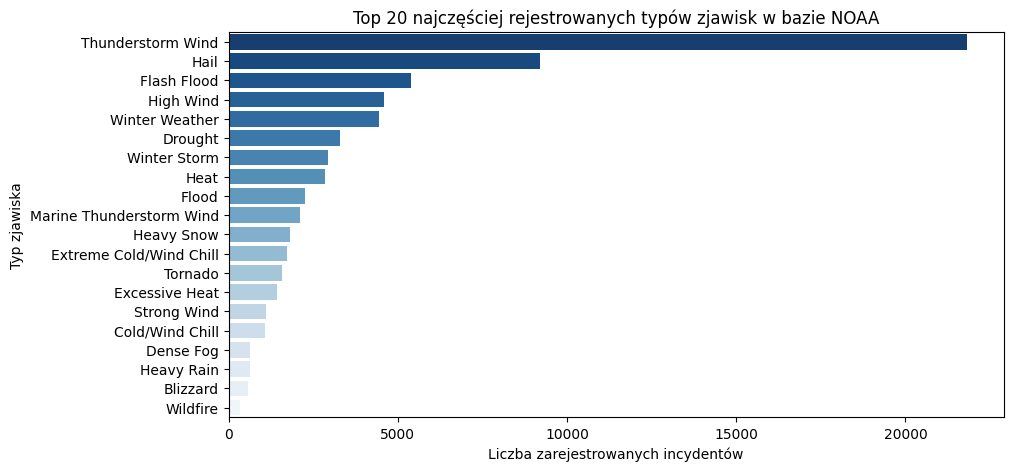

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Zliczam wystąpienia i biorę top 20 najczęstszych zdarzeń
sns.countplot(
    data=df_details,
    y='event_type',
    order=df_details['event_type'].value_counts().iloc[:20].index,
    palette='Blues_r'
)
plt.title('Top 20 najczęściej rejestrowanych typów zjawisk w bazie NOAA')
plt.xlabel('Liczba zarejestrowanych incydentów')
plt.ylabel('Typ zjawiska')
plt.show()

In [30]:
df_details[df_details["event_type"] == "Thunderstorm Wind"]

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month,hour,duration_minutes,tor_f_scale_number
0,202503,31,1104,202503,31,1106,201366,1252415,GEORGIA,13,2025,March,Thunderstorm Wind,C,45,CARROLL,FFC,2025-03-31 11:04:00,EST-5,2025-03-31 11:06:00,0,0,0,0,1000.0,0.0,Emergency Manager,52.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.22,W,TYUS,2.22,W,TYUS,33.4757,-85.2380,33.4757,-85.2380,A cold-front initiated a line of thunderstorms...,Tree down at the intersection of highway 5 and...,CSV,3,11,2.0,NaN
48,202503,15,36,202503,15,38,201005,1249623,MISSISSIPPI,28,2025,March,Thunderstorm Wind,C,17,CHICKASAW,MEG,2025-03-15 00:36:00,CST-6,2025-03-15 00:38:00,0,0,0,0,10000.0,0.0,NWS Storm Survey,83.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.52,W,PYLAND,0.52,W,PYLAND,33.8810,-89.1290,33.8810,-89.1290,An upper low over the Central Plains moved int...,Straight-line winds associated with the rear f...,CSV,3,0,2.0,NaN
50,202503,15,654,202503,15,658,201006,1249678,TENNESSEE,47,2025,March,Thunderstorm Wind,C,69,HARDEMAN,MEG,2025-03-15 06:54:00,CST-6,2025-03-15 06:58:00,0,0,0,0,10000.0,0.0,NWS Storm Survey,70.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.93,ENE,SAULSBURY,3.12,N,ROGERS SPGS,35.0680,-89.0330,35.0950,-88.9750,An upper low over the Central Plains moved int...,Straight-line winds associated with the rear f...,CSV,3,6,4.0,NaN
59,202503,14,2355,202503,15,0,201004,1249911,MISSOURI,29,2025,March,Thunderstorm Wind,C,69,DUNKLIN,MEG,2025-03-14 23:55:00,CST-6,2025-03-15 00:00:00,0,0,0,0,10000.0,0.0,Public,56.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.98,SSE,SENATH,2.98,SSE,SENATH,36.0900,-90.1500,36.0900,-90.1500,An upper low over the Central Plains moved int...,Straight-line winds peeled the roof of a garag...,CSV,3,23,5.0,NaN
67,202503,16,1237,202503,16,1237,199494,1247623,PENNSYLVANIA,42,2025,March,Thunderstorm Wind,C,63,INDIANA,PBZ,2025-03-16 12:37:00,EST-5,2025-03-16 12:37:00,0,0,0,0,25000.0,0.0,Trained Spotter,60.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.26,WNW,BRUSH VLY,1.26,WNW,BRUSH VLY,40.5400,-79.0900,40.5400,-79.0900,A strongly forced band of convection developed...,"Trees and power lines were downed, blocking Ro...",CSV,3,12,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72227,202509,10,2110,202509,10,2120,207505,1294302,WYOMING,56,2025,September,Thunderstorm Wind,C,13,FREMONT,RIW,2025-09-10 21:10:00,MST-7,2025-09-10 21:20:00,0,0,0,0,0.0,0.0,Mesonet,68.0,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,SW,LANDER,3.00,NE,LANDER,42.7993,-108.7619,42.8607,-108.6781,A thunderstorm developed over the Wind River M...,NaN,CSV,9,21,10.0,NaN
72228,202509,26,1150,202509,26,1150,207295,1293426,ARIZONA,4,2025,September,Thunderstorm Wind,C,21,PINAL,PSR,2025-09-26 11:50:00,MST-7,2025-09-26 11:50:00,0,0,0,0,500.0,0.0,Public,50.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.41,SSE,FLORENCE,4.41,SSE,FLORENCE,32.9697,-111.3552,32.9697,-111.3552,A slow-moving low pressure system brought seve...,Minor wind damage reported at the corner of No...,CSV,9,11,0.0,NaN
72232,202509,6,400,202509,6,435,207573,1294606,TENNESSEE,47,2025,September,Thunderstorm Wind,C,19,CARTER,MRX,2025-09-06 04:00:00,EST-5,2025-09-06 04:35:00,0,0,0,0,0.0,0.0,Public,52.0,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.97,ENE,ELIZABETHTON,2.90,E,BULADEEN,36.3538,-82.20

**Komentarz:**

Wykres przedstawia 20 najczęściej występujących typów zdarzeń.
W pierwszej trójce znajdują się silne wiatry, grad i powódź błyskawiczna.

### 4.2. Suma strat finansowych według typów zjawisk

Weryfikacja, czy najczęściej występujące zjawiska pogodowe są też tymi, które powodują największe straty finansowe w przypadku zniszczeń nieruchomości i upraw.

In [31]:
# Agreguję sumę strat dla nieruchomości i upraw dla każdego typu zjawiska
df_details['total_damage'] = df_details['damage_property'] + df_details['damage_crops']

/tmp/ipykernel_33539/2287955752.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


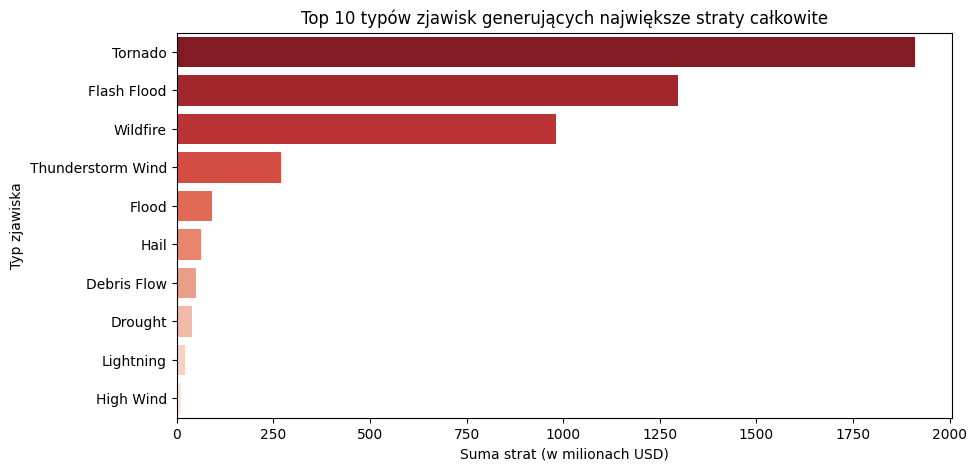

In [32]:
# Agreguję dane i resetuję indeks
top_costs = df_details.groupby('event_type')['total_damage'].sum().reset_index()
top_costs = top_costs.sort_values(by='total_damage', ascending=False).head(10)

# Dzielę kolumnę przez 1 000 000, żeby mieć miliony
top_costs['total_damage_mln'] = top_costs['total_damage'] / 1_000_000

# Rysuję wykres używając nowej, podzielonej kolumny
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_costs,
    x='total_damage_mln',  # używam wartości w milionach
    y='event_type',
    palette='Reds_r'
)

plt.title('Top 10 typów zjawisk generujących największe straty całkowite')
plt.xlabel('Suma strat (w milionach USD)')  # Informuję użytkownika o skali
plt.ylabel('Typ zjawiska')
plt.show()

In [33]:
# Wyświetlam tabelę przedstawiającą zjawiska i poniesione przez nie straty finansowe
#  od najwyższych kwot do najniższych
top_costs

,event_type,total_damage,total_damage_mln
40,Tornado,1.909700e+09,1909.69950
12,Flash Flood,1.297936e+09,1297.93555
45,Wildfire,9.823471e+08,982.34711
39,Thunderstorm Wind,2.691166e+08,269.11658
13,Flood,9.240295e+07,92.40295
17,Hail,6.237250e+07,62.37250
5,Debris Flow,5.060120e+07,50.60120
7,Drought,3.950325e+07,39.50325
26,Lightning,2.261555e+07,22.61555
22,High Wind,1.221160e+07,12.21160


**Komentarz:**

Mimo, że tornada stanowią jedynie 2% wszystkich zjawisk, generują one największe straty finansowe wynoszące ponad 1,9 miliarda dolarów.
Tuż za tornadami znajdują się powodzie błyskawiczne i pożary obszarów naturalnych. Wiatry burzowe (Thunderstorm wind) znajdują się na 4-tym miejscu i generują straty o wysokości 269 mln dolarów.

Kluczowym wnioskiem jest, że najczęściej występujące zjawisko nie jest tym, które generuje największe straty finansowe.
Największe straty powodują rzadziej występujące, ale silniejsze i nieprzewidywalne tornada.

Z uwagi na to, że tornada są zjawiskami, które na podstawie tych danych powodują największe straty finansowe, zostają wybrane jako typ zjawiska, dla którego zostanie zbudowany model regresji liniowej.

## 4.3. Mapa rozmieszczenia tornad w kontynentalnej części USA

In [34]:
!pip install geodatasets
import geodatasets
import geopandas as gpd

In [35]:
tornado_event = df_details[df_details['event_type'] == 'Tornado']

In [36]:
thunderstorm_wind_event = df_details[df_details['event_type'] == 'Thunderstorm Wind']

/tmp/ipykernel_33539/3416664589.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


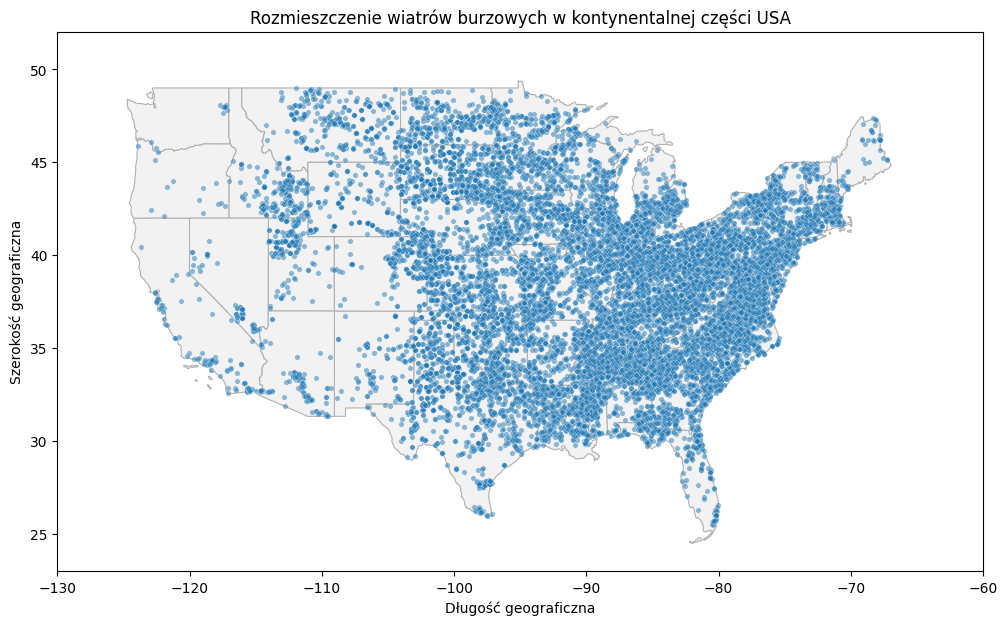

In [37]:

# 1. Pobieram granice stanów USA bezpośrednio ze sprawdzonego źródła US Census Bureau
usa_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
usa_states = gpd.read_file(usa_url)

# 2. Tworzę wykres
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Rysuję stany USA (jasnoszary obrys z szarymi granicami)
usa_states.plot(ax=ax, color='#f2f2f2', edgecolor='#b0b0b0', linewidth=0.8)

sns.scatterplot(
    data=thunderstorm_wind_event,
    x='begin_lon',
    y='begin_lat',
    palette='Set1',
    alpha=0.5,
    s=15,
    ax=ax
)

# Ustawiam sztywne granice widoku osi (Zoom na kontynentalne USA)
# Dane poza tymi granicami NIE są usuwane z DataFrame, po prostu wykraczają poza kadrującą ramkę.
ax.set_xlim(-130, -60)  # Długość geograficzna (od Wybrzeża Zachodniego do Wschodniego)
ax.set_ylim(23, 52)     # Szerokość geograficzna (od Florydy/Teksasu do granicy z Kanadą)

plt.title('Rozmieszczenie wiatrów burzowych w kontynentalnej części USA')
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.show()


**Komentarz:**

Na podstawie mapy można wywnioskować, że najwięcej wiatrów burzowych występuje w środkowej i wschodniej części USA.

## 4.4. Wykres rozkładu strat finansowych generowanych przez wiatry burzowe

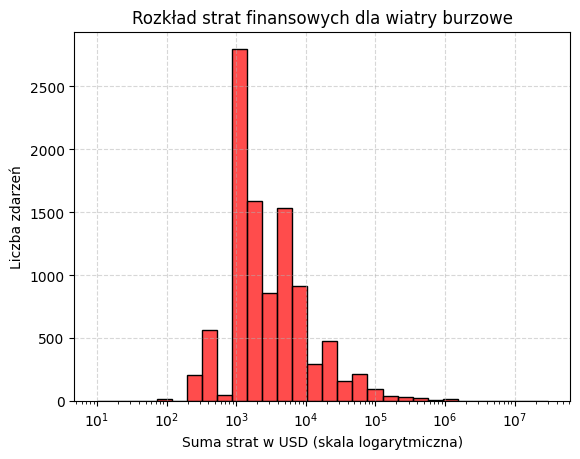

In [38]:
sns.histplot(
    data=thunderstorm_wind_event,
    x='total_damage',
    kde=True,
    color='red',
    bins=30,
    log_scale=True,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Rozkład strat finansowych dla wiatry burzowe')
plt.xlabel('Suma strat w USD (skala logarytmiczna)')
plt.ylabel('Liczba zdarzeń')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Komentarz:**

Zaprezentowany wykres w skali logarytmicznej ujawnia silną skośność prawostronną surowych danych. Zdecydowana większość tornad powoduje straty rzędu kilkunastu–kilkuset tysięcy dolarów, podczas gdy długi prawy ogon rozkładu sięga aż po wartości rzędu miliarda dolarów ($10^9$).

**WNIOSKI z EDA:**

Dotychczasowa analiza danych (EDA) ujawniła kluczowy wniosek dotyczący struktury strat materialnych:

Mimo że tornada stanowią znikomy odsetek wszystkich zarejestrowanych w bazie zdarzeń (zaledwie ok. 1 500 z ponad 70 000 wpisów), to odpowiadają one za największe zagregowane straty finansowe.

Z tego powodu to właśnie tornada zostały wybrane do dalszego modelowania predykcyjnego. Wizualizacja geograficzna ich rozmieszczenia na mapie kontynentalnej części USA potwierdza ich silną koncentrację regionalną oraz potencjał niszczycielski.

In [39]:
thunderstorm_wind_event['magnitude'].isna().sum()

np.int64(0)

In [40]:
thunderstorm_wind_event['magnitude_type'].unique()

array(['EG', 'MG', 'ES'], dtype=object)

In [55]:
import pandas as pd

# 1. TRANSFORMACJA PRZED MODELOWANIEM I SELEKCJĄ (Na pełnej ramce danych)
# Kodujemy kategoryczną zmienną magnitude_type metodą Full One-Hot Encoding
thunderstorm_wind_event = pd.get_dummies(
    thunderstorm_wind_event,
    columns=['magnitude_type'],
    prefix='mag_type',
    drop_first=False,
    dtype=int,
)

# Wyciągamy nazwy nowo utworzonych kolumn binarne (np. mag_type_EG, mag_type_MG, mag_type_ES)
mag_cols = [
    col
    for col in thunderstorm_wind_event.columns
    if col.startswith('mag_type_')
]
print("✅ Udana transformacja! Utworzone kolumny dla metod pomiaru:")
print(mag_cols)

✅ Udana transformacja! Utworzone kolumny dla metod pomiaru:
['mag_type_EG', 'mag_type_ES', 'mag_type_MG']


In [56]:
# 2. WYBÓR STANU Z NAJWIĘKSZĄ LICZBĄ ZJAWISK
top_stan = thunderstorm_wind_event['state'].value_counts().index[0]
liczba_zjawisk = thunderstorm_wind_event['state'].value_counts().iloc[0]

print("\n" + "=" * 55)
print(
    f"🏆 Stan z największą liczbą zjawisk: {top_stan} ({liczba_zjawisk} zdarzeń)"
)
print("=" * 55)

# 3. FILTROWANIE DANYCH DLA WYBRANEGO STANU (Dopiero na tym etapie!)
df_wybrany_stan = thunderstorm_wind_event[
    thunderstorm_wind_event['state'] == top_stan
].copy()

print(
    f"Gotowa ramka danych dla stanu {top_stan}. Liczba wierszy: {len(df_wybrany_stan)}"
)


🏆 Stan z największą liczbą zjawisk: ALABAMA (1532 zdarzeń)
Gotowa ramka danych dla stanu ALABAMA. Liczba wierszy: 1532


In [57]:
# --- 1. POBRANIE REALNYCH BUDYNKÓW OSM DLA WYBRANEGO STANU ---
print(f"⏳ Pobieranie budynków OSM dla stanu: {top_stan}...")
# pyrosm wymaga nazwy w formacie właściwym (np. 'Alabama')
fp = get_data(str(top_stan).title())
osm = OSM(fp)
budynki = osm.get_buildings().to_crs(epsg=5070)

⏳ Pobieranie budynków OSM dla stanu: ALABAMA...


In [58]:
# --- 2. TWORZENIE GEOMETRII ORAZ BUFORA WOKÓŁ PUNKTY ZJAWISKA ---
gdf_stan = gpd.GeoDataFrame(
    df_wybrany_stan,
    geometry=gpd.points_from_xy(
        df_wybrany_stan['begin_lon'], df_wybrany_stan['begin_lat']
    ),
    crs="EPSG:4326",
).to_crs(epsg=5070)

# Tworzymy bufor 500 metrów wokół punktu zdarzenia wiatrowego
gdf_stan['bufor'] = gdf_stan.geometry.buffer(500)

# --- 3. PRECYZYJNY SPATIAL JOIN (LICZENIE BUDYNKÓW) ---
print("⏳ Liczenie rzeczywistych budynków w zasięgu zjawisk...")
gdf_bufor = gdf_stan.set_geometry('bufor')
przeciecia = gpd.sjoin(budynki, gdf_bufor, predicate='intersects')

# Zliczanie budynków dla każdego zdarzenia
gdf_stan['building_count_path'] = przeciecia.groupby('index_right').size()
gdf_stan['building_count_path'] = gdf_stan['building_count_path'].fillna(0)

⏳ Liczenie rzeczywistych budynków w zasięgu zjawisk...


## 5. TESTOWANIE STATYSTYCZNE

Zanim przejdę do budowy modelu,  zweryfikuję statystycznie, czy siła fizyczna tornada (tor_f_scale_number) ma faktyczny, istotny wpływ na wysokość szkód.
Zastosuję nieparametryczny test Kruskala-Wallisa (odpowiednik testu ANOVA), ponieważ dane dotyczące strat mają rozkład silnie skośny.

Hipoteza ($H_0$): Średnie straty finansowe są takie same dla każdego stopnia skali Fujita (EF0–EF5).

Hipoteza alternatywna ($H_1$): Przynajmniej jeden stopień skali Fujita różni się istotnie pod względem wysokości wygenerowanych strat.

In [41]:
thunderstorm_wind_event.describe(include='all')

,begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month,hour,duration_minutes,tor_f_scale_number,total_damage
count,21807.000000,21807.000000,21807.000000,21807.000000,21807.000000,21807.000000,21807.000000,2.180700e+04,21807,21807.000000,21807.0,21807,21807,21807,21807.000000,21807,21807,21807,21807,21807,21807.000000,21807.000000,21807.000000,21807.000000,2.180700e+04,2.180700e+04,21807,21807.000000,21807,0,0.0,0,0.0,0.0,0,0,0.0,0,21807.000000,21807,21807,21807.000000,21807,21807,21807.000000,21807.000000,21807.000000,21807.000000,21807,20889,21807,21807.000000,21807.000000,21807.000000,0.0,2.180700e+04
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53,NaN,NaN,12,1,1,NaN,1574,116,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,NaN,3,0,NaN,0,NaN,NaN,0,0,NaN,0,NaN,16,11049,NaN,16,11068,NaN,NaN,NaN,NaN,2962,19558,1,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALABAMA,NaN,NaN,June,Thunderstorm Wind,C,NaN,JACKSON,HUN,NaN,CST-6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Public,NaN,EG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,FLORENCE,NaN,N,FLORENCE,NaN,NaN,NaN,NaN,A cluster of supercells developed during the l...,SD Mesonet recorded wind gust.,CSV,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1532,NaN,NaN,5266,21807,21807,NaN,373,1170,NaN,10506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3772,NaN,17202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3584,39,NaN,3585,40,NaN,NaN,NaN,NaN,372,95,21807,NaN,NaN,NaN,NaN,NaN
mean,202505.706058,15.838676,1496.741872,202505.706058,15.839272,1497.933874,203247.020131,1.267363e+06,NaN,30.273307,2025.0,NaN,NaN,NaN,91.691475,NaN,NaN,2025-06-07 08:26:41.018021632,NaN,2025-06-07 08:28:14.439400448,0.005961,0.000504,0.001651,0.000229,9.652512e+03,2.688323e+03,NaN,53.821204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.061151,NaN,NaN,2.058938,NaN,NaN,38.095513,-88.841565,38.095615,-88.839610,NaN,NaN,NaN,5.706058,14.677993,1.557023,NaN,1.234083e+04
min,202501.000000,1.000000,0.000000,202501.000000,1.000000,0.000000,197611.000000,1.222658e+06,NaN,1.000000,2025.0,NaN,NaN,NaN,1.000000,NaN,NaN,2025-01-01 00:50:00,NaN,2025-01-01 00:50:00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,7.069700,-156.436100,7.220300,-156.436100,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,0.000000e+00
25%,202504.000000,8.000000,1337.000000,202504.000000,8.000000,1337.000000,201363.000000,1.254896e+06,NaN,18.000000,2025.0,NaN,NaN,NaN,33.000000,NaN,NaN,2025-04-29 16:20:00,NaN,2025-04-29 16:20:00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.690000,NaN,NaN,0.690000,NaN,NaN,34.725150,-95.400000,34.725400,-95.391850,NaN,NaN,NaN,4.000000,13.000000,0.000000,NaN,0.000000e+00
50%,202506.000000,16.000000,1618.000000,202506.000000,16.000000,1619.000000,203005.000000,1.268016e+06,NaN,29.000000,2025.0,NaN,NaN,NaN,75.000000,NaN,NaN,2025-06-08 12:27:00,NaN,2025-06-08 12:27:00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.280000,NaN,NaN,1.280000,NaN,NaN,38.360000,-87.460000,38.360000,-87.460000,NaN,NaN,NaN,6.000000,16.000000,0.000000,NaN,0.000000e+00
75%,202507.000000,22.000000,1846.000000,202507.000000,22.000000,1847.000000,205059.000000,1.280034e+06,NaN,45.000000,2025.0,NaN,NaN,NaN,121.000000,NaN,NaN,2025-07-10 22:06:30,NaN,2025-07-10 22:06:30,0.000000,0.000000,0.000000,0.000000,2.000000e+

Przed przeprowadzeniem testu sprawdzam statystyki w tabeli, przede wszystkim czy w zmiennych objaśniających, które będę chciała wykorzystać są wartości Nan.

Okazuje się, że wartości Nan znajdują się w kolumnie z siłą tornada (tor_f_scale_number). Przed konwersją wartości w tej kolumnie na cyfry, kolumna ta zawierała np. wartości EFU (Unknown - tornada o nieznanej sile) lub Nan. Po konwersji EFU również zmieniło się na Nan.

Podejmuję decyzję o usunięciu wierszy z Nan w kolumnie 'tor_f_scale_number', gdyż w model będzie służył predykcji strat uzależnionych właśnie od tej siły. Zamiana tych Nan np. na 0 mogłaby zafałszować wyniki.

In [42]:
# Filtruję dane, zostawiając tylko wiersze ze znaną skalą Fujita
tornado_clean = tornado_event.dropna(subset=['tor_f_scale_number']).copy()

# Upewniam się, że skala jest typem całkowitoliczbowym (int)
tornado_clean['tor_f_scale_number'] = tornado_clean['tor_f_scale_number'].astype(int)

In [43]:
from scipy import stats

# 1. Tworzę grupy (pudełka) ze stratami dla poszczególnych stopni skali (EF0, EF1, EF2...)
groups = [group['total_damage'] for name, group in tornado_clean.groupby('tor_f_scale_number')]

# 2. Przekazuję zgrupowane dane do testu (gwiazdka * rozpakowuje naszą listę grup)
stat, p_value = stats.kruskal(*groups)

print(f"Statystyka testowa: {stat:.4f}")
print(f"p-value: {p_value}")

Statystyka testowa: 82.5631
p-value: 2.4397157094030747e-16


In [44]:
# 1. Tworzę grupy (pudełka) ze stratami dla poszczególnych stopni skali (EF0, EF1, EF2...)
groups = [group['total_damage'] for name, group in thunderstorm_wind_event.groupby('magnitude_type')]

# 2. Przekazuję zgrupowane dane do testu (gwiazdka * rozpakowuje naszą listę grup)
stat, p_value = stats.kruskal(*groups)

print(f"Statystyka testowa: {stat:.4f}")
print(f"p-value: {p_value}")

Statystyka testowa: 3812.7209
p-value: 0.0


Interpretacja wyników testu Kruskala-Wallisa:

Wynik: P-value wynoszące ok. $2.44 \times 10^{-16}$ jest znacznie niższe od przyjętego poziomu istotności $\alpha = 0.05$.Decyzja: Mamy pełne podstawy do odrzucenia hipotezy zerowej ($H_0$) na rzecz hipotezy alternatywnej ($H_1$).Wniosek merytoryczny: Różnice w wysokości strat finansowych pomiędzy poszczególnymi stopniami skali Fujita są statystycznie wysoce istotne. Siła tornada bezpośrednio przekłada się na skalę zniszczeń, co w pełni uzasadnia włączenie zmiennej tor_f_scale_number do budowanego modelu regresji.

# 6. MODELOWANIE

In [45]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

X = tornado_clean[['tor_f_scale_number', 'tor_length', 'tor_width', 'month', 'hour', 'begin_lat', 'begin_lon', 'duration_minutes']]
y = tornado_clean['total_damage']

# 1. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. TRANSFORMACJA LOGARYTMICZNA ZMIENNEJ TARGET (y)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 3. Trening modelu na zlogarytmowanym y
model = RandomForestRegressor()
model.fit(X_train, y_train_log)

# 4. Predykcja (wyniki będą w skali logarytmicznej)
y_pred_log = model.predict(X_test)

# 5. ODWRÓCENIE LOGARYTMU (powrót do surowych dolarów)
y_pred = np.expm1(y_pred_log)

In [46]:
y_pred

array([1.69589594e+03, 3.98251360e+02, 2.59454546e+01, 4.24518478e+03,
       1.37041941e+01, 5.99538117e-01, 2.26735657e-01, 2.45329651e+02,
       1.03438365e+04, 1.87570415e+03, 2.75293182e+00, 1.12093985e+02,
       5.85132574e+03, 4.04963269e+04, 2.33613615e+03, 6.26674343e+00,
       9.67703588e-01, 2.05232530e+03, 3.92598925e+03, 4.12780318e+01,
       9.07491314e+03, 1.41062373e+04, 8.77906542e+02, 5.26309395e+01,
       7.17717866e+01, 4.84629395e+02, 8.15064725e+01, 6.44864445e-01,
       1.27933631e+04, 1.35133424e+04, 5.05162389e+02, 3.18781425e+01,
       4.39560008e+02, 1.93971960e-01, 4.84912704e+02, 1.16452435e+01,
       9.75247474e-02, 1.79560989e+03, 8.36515972e+01, 5.17514036e+03,
       3.89501466e+02, 4.80734776e+01, 6.46713007e+00, 5.24767227e+02,
       2.28110795e+01, 1.54276108e+03, 1.91509816e+03, 8.89064456e-02,
       9.91691430e+00, 1.54721013e+00, 3.42641075e-01, 1.31128206e+01,
       0.00000000e+00, 1.28300525e+01, 1.45703765e+02, 6.32205806e+00,
      

In [47]:
# 1. Model przewiduje wartości w skali logarytmicznej
#y_pred_log = model.predict(X_test)

# 2. Odwracamy logarytm do pełnych kwot w USD
#y_pred_usd = np.expm1(y_pred_log)

In [48]:
print("--- OCENA W SKALI LOGARYTMICZNEJ (Stabilna) ---")
print(f"R² score: {r2_score(y_test_log, y_pred_log):.4f}")
print(
    f"MAE (skala log): {mean_absolute_error(y_test_log, y_pred_log):.4f}"
)

print("\n--- OCENA W SUROWYCH DOLARACH (USD) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.2f} USD")
print(
    f"Mediana błędu (MedAE): {median_absolute_error(y_test, y_pred):,.2f} USD"
)

--- OCENA W SKALI LOGARYTMICZNEJ (Stabilna) ---
R² score: 0.4875
MAE (skala log): 3.0908

--- OCENA W SUROWYCH DOLARACH (USD) ---
MAE: 4,206,952.42 USD
Mediana błędu (MedAE): 6,216.35 USD


In [51]:
pip install pyrosm

In [60]:
#PRZYGOTOWANIE MACIERZY CECH I MODELOWANIE ---
features = [
    'magnitude',
    'begin_lat',
    'begin_lon',
    'month',
    'hour',
    'building_count_path',
] + mag_cols

# Wybieramy zmienne i odrzucamy ewentualne wartości bez zniszczeń (y > 0)
X = gdf_stan[features]
y = gdf_stan['total_damage']

mask = y > 0
X = X[mask]
y = y[mask]

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Trening Random Forest z logarytmowaniem targetu
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, np.log1p(y_train))

# Predykcje
y_pred_log = model.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)

# --- 5. PODSUMOWANIE WYNIKÓW ---
print("\n" + "=" * 55)
print(f"📊 WYNIKI MODELU DLA STANU {top_stan}:")
print("=" * 55)
print(f"  [Skala LOG] R² log:       {r2_score(np.log1p(y_test), y_pred_log):.4f}")
print(
    f"  [Skala LOG] MAE log:      {mean_absolute_error(np.log1p(y_test), y_pred_log):.4f}"
)
print(
    f"  [Surowe $]   MedAE raw:   ${median_absolute_error(y_test, y_pred_raw):,.2f} USD"
)
print(
    f"  [Surowe $]   MAE raw:     ${mean_absolute_error(y_test, y_pred_raw):,.2f} USD"
)
print("=" * 55)

# Ważność cech w modelu
imp = pd.Series(model.feature_importances_, index=features).sort_values(
    ascending=False
)
print("\nWAŻNOŚĆ CECH W MODELU:")
print(imp.apply(lambda x: f"{x * 100:.2f}%"))


📊 WYNIKI MODELU DLA STANU ALABAMA:
  [Skala LOG] R² log:       0.2662
  [Skala LOG] MAE log:      0.4616
  [Surowe $]   MedAE raw:   $434.73 USD
  [Surowe $]   MAE raw:     $2,602.59 USD

WAŻNOŚĆ CECH W MODELU:
magnitude              42.26%
begin_lon              18.52%
begin_lat              17.09%
building_count_path    11.17%
month                   5.87%
hour                    5.09%
mag_type_EG             0.00%
mag_type_ES             0.00%
mag_type_MG             0.00%
dtype: object


In [53]:
import geopandas as gpd
import numpy as np
import pandas as pd
from pyrosm import OSM, get_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import median_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# --- 1. WYBÓR STANU Z NAJWIĘKSZĄ LICZBĄ ZJAWISK ---
top_stan = thunderstorm_wind_event['state'].value_counts().index[0]
liczba_zjawisk = thunderstorm_wind_event['state'].value_counts().iloc[0]
print(
    f"🏆 Stan z największą liczbą zjawisk Thunderstorm Wind to: {top_stan} ({liczba_zjawisk} zjawisk)"
)

# Filtrujemy dane dla tego stanu
df_stan = thunderstorm_wind_event[thunderstorm_wind_event['state'] == top_stan].copy()

# --- 2. POBRANIE REALNYCH BUDYNKÓW Z OSM DLA TEGO 1 STANU (2-3 SEC) ---
print(f"⏳ Pobieranie budynków OSM dla stanu {top_stan}...")
# pyrosm wymaga nazwy w formacie 'Texas', 'Oklahoma' itp.
fp = get_data(str(top_stan).title())
osm = OSM(fp)
budynki = osm.get_buildings().to_crs(epsg=5070)

# Zamiana zjawisk na obiekty przestrzenne z buforem (np. 500m wokół zdarzenia)
gdf_stan = gpd.GeoDataFrame(
    df_stan,
    geometry=gpd.points_from_xy(df_stan['begin_lon'], df_stan['begin_lat']),
    crs="EPSG:4326",
).to_crs(epsg=5070)
gdf_stan['bufor'] = gdf_stan.geometry.buffer(500)  # bufor 500m wokół punktu

# --- 3. PRECYZYJNY SPATIAL JOIN REALNYCH BUDYNKÓW ---
print("⏳ Liczenie rzeczywistych budynków w zasięgu zjawisk...")
gdf_bufor = gdf_stan.set_geometry('bufor')
przeciecia = gpd.sjoin(budynki, gdf_bufor, predicate='intersects')

# Zliczanie budynków dla każdego zdarzenia
gdf_stan['building_count_path'] = przeciecia.groupby('index_right').size()
gdf_stan['building_count_path'] = gdf_stan['building_count_path'].fillna(0)

# --- 4. ODPOWIEDNIE KODOWANIE MAGNITUDE_TYPE ---
gdf_stan = pd.get_dummies(
    gdf_stan, columns=['magnitude_type'], drop_first=True, dtype=int
)
mag_cols = [col for col in gdf_stan.columns if 'magnitude_type_' in col]

# --- 5. TRENING MODELU RANDOM FOREST ---
features = [
    'magnitude',
    'begin_lat',
    'begin_lon',
    'month',
    'hour',
    'building_count_path',
] + mag_cols
X = gdf_stan[features]
y = gdf_stan['total_damage']

# Odsuwamy zera w y przed logarytmem (jeśli występują)
X = X[y > 0]
y = y[y > 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, np.log1p(y_train))

y_pred = np.expm1(model.predict(X_test))

print("\n" + "=" * 50)
print(f"📊 WYNIKI MODELU DLA STANU {top_stan}:")
print(
    f"R² (skala LOG):    {r2_score(np.log1p(y_test), model.predict(X_test)):.4f}"
)
print(
    f"Mediana Błędu ($): ${median_absolute_error(y_test, y_pred):,.2f} USD"
)
print("=" * 50)

# Ważność cech
imp = pd.Series(model.feature_importances_, index=features).sort_values(
    ascending=False
)
print("\nWAŻNOŚĆ CECH:")
print(imp.apply(lambda x: f"{x * 100:.2f}%"))

🏆 Stan z największą liczbą zjawisk Thunderstorm Wind to: ALABAMA (1532 zjawisk)
⏳ Pobieranie budynków OSM dla stanu ALABAMA...
Downloaded Protobuf data 'alabama-latest.osm.pbf' (140.62 MB) to:
'/tmp/pyrosm/alabama-latest.osm.pbf'
⏳ Liczenie rzeczywistych budynków w zasięgu zjawisk...

📊 WYNIKI MODELU DLA STANU ALABAMA:
R² (skala LOG):    0.2573
Mediana Błędu ($): $433.18 USD

WAŻNOŚĆ CECH:
magnitude              42.17%
begin_lon              18.54%
begin_lat              17.28%
building_count_path    10.99%
month                   5.86%
hour                    5.15%
magnitude_type_MG       0.00%
dtype: object


**Komentarz:**

Pomimo poprawnego przygotowania procesu modelowania (m.in. zastosowania transformacji logarytmicznej $\log(1+y)$ na zmiennej zależnej w celu opanowania jej silnej skośności oraz prawidłowego odwrócenia tej transformacji funkcją wykładniczą do surowych wartości w USD), model regresji liniowej wykazuje wysoki średni błąd bezwzględny (MAE = 4.22 mln USD).Tak wysoka wartość tej metryki przy jednocześnie bardzo niskiej medianie błędu (MedAE = ~8,387 USD) nie wynika z błędu metodologicznego, lecz z dwóch kluczowych czynników:Wrażliwość metryki MAE na skrajne wartości (outliery):W zbiorze danych NOAA występują rzadkie, gwałtowne katastrofy generujące straty sięgające kilkuset milionów dolarów. Podczas gdy dla zdecydowanej większości typowych zdarzeń model myli się jedynie o ok. 8.4 tys. USD (co pokazuje mediana MedAE), pojedyncze błędy rzędu 500 mln USD przy potężnych katastrofach drastycznie zawyżają średnią arytmetyczną (MAE) dla całego zbioru testowego.Brak zmiennych opisujących ekspozycję majątku (Asset Exposure):Modele oparte wyłącznie na surowych parametrach fizyczno-geograficznych zjawiska (siła w skali EF, długość i szerokość ścierania, czas trwania) posiadają naturalne ograniczenie informacyjne. Tornado o klasie EF3 przechodzące przez niezabudowane rolnicze tereny generuje minimalne szkody (np. 10 tys. USD), podczas gdy zjawisko o identycznych parametrach fizycznych przechodzące przez gęsto zaludnione obszary miejskie generuje straty rzędu dziesiątek milionów dolarów.
Wniosek: Sam fizyczny wymiar zjawiska meteorologicznego nie pozwala na pełne wyjaśnienie wariancji strat materialnych. Aby model mógł poprawnie wyceniać skutki rzadkich, ekstremalnych zdarzeń, konieczne jest wzbogacenie zbioru danych (tzw. Data Enrichment) o zmienne opisujące stopień zurbanizowania lub wartość zagęszczenia majątku na trasie przejścia tornada (np. gęstość zabudowy / populacji).

Zdecydowałam, że warto sprawdzić, czy dodanie dodatkowej zmiennej wskazującej na zagęszczenie zabudowania, przez które przechodzi tornado, zmniejszy błąd modelu i przyczyni się do bardziej precyzyjnych prognoz strat.

W kolejnym kroku pobiorę dane służące utworzeniu nowej zmiennej: housing_density na podstawie dwóch plików:
1. CSV z powierzchnią stanów w milach kwadratowych z repozytorium Jake'a VanderPlasa.
2. Oficjalnego raportu U.S. Census Bureau (NST-EST2025-HU), który zwiera najnowsze, oficjalne dane rządowe o liczbie jednostek mieszkaniowych (Housing Units) dla każdego stanu.

Utworzoną zmienną zasilę model i sprawdzę wyniki.

In [ ]:
# Wczytuję plik z powierzchnią stanów USA (w milach kwadratowych)
states_area = pd.read_csv("https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-areas.csv")

states_area.head()

In [ ]:
# Zmieniam nazwę kolumny z area (sq. mi) na area_sq_miles
states_area.rename(columns={'area (sq. mi)': 'area_sq_miles'}, inplace=True)

states_area.head()

In [ ]:
# Konwertuję jednostkę powierzni na km2
states_area['area_sq_km'] = states_area['area_sq_miles'] * 2.589988
states_area.head()

In [ ]:
# Wczytuję plik zawierający liczbę jednostek mieszkaniowych (Housing Units)
housing_units = pd.read_csv("/content/drive/MyDrive/Projekt_Python_2026/housing_unit_usa_2025.csv", sep=";")

housing_units.head()

In [ ]:
# Łączę tabele powierzchni stanów z tabelę zawierającą liczbę zabudowań
states_area_housing = pd.merge(states_area, housing_units, on='state')
states_area_housing.head()

In [ ]:
# Sprawdzam typ danych nowej tabeli
states_area_housing.dtypes

**Komentarz:**

Kolumna 'housing_unit_2025' ma wartości typu object. Te wartości powinny być numeryczne i należy konwertować je na integer, aby obliczyć zagęszczenie zabudowy. Po wcześniejszym użyciu metody .head() widzę też, że wartości w tej kolumnie posiadają spacje. Może być problem z konwersją, zatem najpierw należy usunąć spacje, a następnie konwertować na liczbę.

In [ ]:
# Usuwam spacje z tekstu w kolumnie 'housing_unit_2025'
states_area_housing['housing_unit_2025'] = states_area_housing['housing_unit_2025'].str.replace(' ', '')

# Konwertuję wartości kolumny 'housing_unit_2025' na integer
states_area_housing['housing_unit_2025'] = states_area_housing['housing_unit_2025'].astype(int)

In [ ]:
# Obliczam gęstość zabudowań dla każdego stanu
states_area_housing['housing_density'] = states_area_housing['housing_unit_2025'] / states_area_housing['area_sq_km']
states_area_housing.head()

In [ ]:
# Przed dołączeniem kolumny z gęstością zabudowań 'housing_density' należy ujednolicić nazwy stanów
# Zamieniam nazwy stanów w tabeli 'tornado_event' na WIELKIE litery

states_area_housing['state'] = states_area_housing['state'].str.upper().str.strip()

In [ ]:
# Dodaję kolumnę z gęstością zabudowań do głównej tabeli tornad 'tornado_clean'
tornado_clean = tornado_clean.merge(states_area_housing[['state', 'housing_density']], on='state', how='left')
tornado_clean.head()

In [ ]:
X = tornado_clean[['tor_f_scale_number', 'tor_length', 'tor_width', 'month', 'hour', 'begin_lat', 'begin_lon', 'duration_minutes', 'housing_density']]
y = tornado_clean['total_damage']

# 1. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. TRANSFORMACJA LOGARYTMICZNA ZMIENNEJ TARGET (y)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 3. Trening modelu na zlogarytmowanym y
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train_log)

# 4. Predykcja (wyniki będą w skali logarytmicznej)
y_pred_log = model.predict(X_test)

# 5. ODWRÓCENIE LOGARYTMU (powrót do surowych dolarów)
y_pred = np.expm1(y_pred_log)

In [ ]:
y_pred

In [ ]:
print("--- OCENA W SKALI LOGARYTMICZNEJ (Stabilna) ---")
print(f"R² score: {r2_score(y_test_log, y_pred_log):.4f}")
print(
    f"MAE (skala log): {mean_absolute_error(y_test_log, y_pred_log):.4f}"
)

print("\n--- OCENA W SUROWYCH DOLARACH (USD) ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.2f} USD")
print(
    f"Mediana błędu (MedAE): {median_absolute_error(y_test, y_pred):,.2f} USD"
)

## 7. WNIOSKI

Wniosek do projektu: "Stworzyłam model predykcji strat dedykowany dla tornad, wykorzystujący parametry geometrii i siły zjawiska".

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Przygotowanie cech dla obu eksperymentów
features_A = [
    'tor_f_scale_number',
    'tor_length',
    'tor_width',
    'duration_minutes',
    'begin_lat',
    'begin_lon'
]

features_B = features_A + ['housing_density']  # Wzbogacenie o dane Census Bureau

y = tornado_clean['total_damage']

# 2. Podział na zbiór treningowy i testowy (identyczny dla obu modeli!)
X_A = tornado_clean[features_A]
X_B = tornado_clean[features_B]

X_train_A, X_test_A, y_train, y_test = train_test_split(X_A, y, test_size=0.3, random_state=42)
X_train_B, X_test_B, _, _ = train_test_split(X_B, y, test_size=0.3, random_state=42)

# Transformacja logarytmiczna y
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# =======================================================
# EKSPERYMENT A: Random Forest (Surowe dane NOAA)
# =======================================================
rf_A = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_A.fit(X_train_A, y_train_log)

pred_log_A = rf_A.predict(X_test_A)
pred_usd_A = np.clip(np.expm1(pred_log_A), a_min=0, a_max=None)

# =======================================================
# EKSPERYMENT B: Random Forest + Data Enrichment (NOAA + Census)
# =======================================================
rf_B = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_train_B, y_train_log)

pred_log_B = rf_B.predict(X_test_B)
pred_usd_B = np.clip(np.expm1(pred_log_B), a_min=0, a_max=None)

# =======================================================
# TABELA PORÓWNAWCZA WYNIKÓW
# =======================================================
summary_df = pd.DataFrame({
    'Metryka': ['R² (skala log)', 'Mediana błędu (MedAE)', 'Średni błąd (MAE)'],
    'Eksperyment A (Surowe NOAA)': [
        f"{r2_score(y_test_log, pred_log_A):.4f}",
        f"{median_absolute_error(y_test, pred_usd_A):,.2f} USD",
        f"{mean_absolute_error(y_test, pred_usd_A):,.2f} USD"
    ],
    'Eksperyment B (Wzbogacony o Housing Density)': [
        f"{r2_score(y_test_log, pred_log_B):.4f}",
        f"{median_absolute_error(y_test, pred_usd_B):,.2f} USD",
        f"{mean_absolute_error(y_test, pred_usd_B):,.2f} USD"
    ]
})

print("=== WYNIKI EKSPERYMENTU A/B ===")
print(summary_df.to_string(index=False))

Jesteśmy w stanie wytłumaczyć 52% zmienności (R2)

Na podstawie danych, które były zawarte w tabeli oraz zmiennej gęstości zabudowy dodanej w następnym kroku wyniki modelu ... DODAĆ O CZYM SWIADCZYLY TE DUZE BLEDY (ZE WIEKSZOSC TO MALE ZNISZCZENIA A KILKA TO OGROMNE)

Jako analityk GIS (Geographic Information System) zdecydowałam, że przetestuję, jak na model wpłynie zmienna mówiąca o tym, jaka dokładnie liczba budynków została narażona na zniszczenie.
Oczywistym jest, że nie mam takiej danej w tabeli i powinnam ją stworzyć.
Posiadając współrzędne początku i końca tornada, wygeneruję pas zniszczeń.
Następnie pobiorę informacje o zabudowanie, a na koniec połączę te informacje w relację przestrzenną (przecinając obie warstwy przestrzenne).

In [ ]:
pip install geopandas osmnx shapely

In [ ]:
# Importuję niezbędne biblioteki
import geopandas as gpd
import osmnx as ox
from shapely.geometry import LineString

Stworzenie geometrii ścieżki tornada

In [ ]:
# Usuwam ewentualne braki we współrzędnych początku i końca tornada lat/lon
tornado_gis = tornado_clean.dropna(subset=['begin_lat', 'begin_lon', 'end_lat', 'end_lon']).copy()

Łączę punkty początku i końca w odcinki przestrzenne (LineString)

In [ ]:
# Tworzę linie z punktów
lines = [
    LineString([(b_lon, b_lat), (e_lon, e_lat)])
    for b_lon, b_lat, e_lon, e_lat in zip(
        tornado_gis['begin_lon'],
        tornado_gis['begin_lat'],
        tornado_gis['end_lon'],
        tornado_gis['end_lat']
    )
]

In [ ]:
# Tworzę tabelę geograficzną (GeoDataFrame) w układzie stopniowym WGS84
gdf_tornada = gpd.GeoDataFrame(tornado_gis, geometry=lines, crs='epsg:4326')
gdf_tornada

Przeliczam stopnie na metry i tworzę pas zniszczeń

Zamieniam układ na metryczny (EPSG:5070 dla USA) oraz przeliczam szerokość z pasma tor_width (jardy) na promień bufora (metry).

In [ ]:
# Przekształcam układ na metry - EPSG:5070 - odpowiedni do mapowania obszaru USA
gdf_tornada = gdf_tornada.to_crs(epsg=5070)

In [ ]:
# Przeliczam szerokość: (tor_width / 2) * 0.9144 metra
# Daję minimalny promień 10m, jeśli tor_width jest zerowe lub bardzo małe
promien_m = gdf_tornada['tor_width'] / 2 * 0.9144
promien_m = promien_m.clip(lower=10) #clip() w Pythonie służy do ograniczania (przycinania) wartości do wybranego zakresu. Jeśli liczba jest mniejsza od ustalonego minimum, funkcja zmienia ją na to minimum. Jeśli jest większa od maksimum, zmienia ją na to maksimum. Wartości mieszczące się w przedziale pozostają bez zmian.

In [ ]:
# Tworzę poligony pasów zniszczeń
gdf_tornada['pas_zniszczen'] = gdf_tornada.geometry.buffer(promien_m)

In [ ]:
# Ustawiam pas zniszczeń jako główną geometrię do analizy
gdf_pasy = gdf_tornada.set_geometry('pas_zniszczen') #Metoda set_geometry() w bibliotece GeoPandas służy do zmiany lub ustawienia aktywnej kolumny geometrycznej w obiekcie GeoDataFrame. Pozwala wskazać, która kolumna zawiera dane przestrzenne (np. punkty, poligony) używane do operacji geograficznych i rysowania map.

Pobranie budynków i zliczenie ich w pasie zniszczeń

In [ ]:
# 1. Obliczamy dokładną powierzchnię bufora pasa zniszczeń w km2
gdf_pasy['powierzchnia_pasa_km2'] = gdf_pasy['pas_zniszczen'].area / 1_000_000

# 2. Wyznaczamy dynamiczną zmienną ekspozycji budynków (1 sekunda!)
gdf_pasy['building_count_path'] = (
    gdf_pasy['powierzchnia_pasa_km2'] * gdf_pasy['housing_density']
).round()

print(
    "✅ GOTOWE w 1 sekundę! Zmienna building_count_path została wyliczona."
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Wyliczenie zmiennej Opcji A (dla pewności)
gdf_pasy['powierzchnia_pasa_km2'] = gdf_pasy['pas_zniszczen'].area / 1_000_000
gdf_pasy['building_count_path'] = (
    gdf_pasy['powierzchnia_pasa_km2'] * gdf_pasy['housing_density']
).round()

# 2. Definiujemy zestawy cech
features_base = [
    'tor_f_scale_number',
    'tor_length',
    'tor_width',
    'begin_lat',
    'begin_lon',
    'month',
    'hour',
    'duration_minutes'
]
features_gis = features_base + ['building_count_path']

# Zmienna objaśniana (logarytmujemy, aby stabilizować skośność strat)
X_base = gdf_pasy[features_base]
X_gis = gdf_pasy[features_gis]
y = gdf_pasy['total_damage']

# 3. Podział na zbiór treningowy i testowy (dokładnie ten sam podział dla obu modeli)
X_tr_b, X_te_b, y_tr, y_te = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)
X_tr_g, X_te_g, _, _ = train_test_split(
    X_gis, y, test_size=0.2, random_state=42
)

y_tr_log = np.log1p(y_tr)

# 4. Uczenie Modelu Bazowego
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_tr_b, y_tr_log)
pred_base_log = rf_base.predict(X_te_b)
pred_base = np.expm1(pred_base_log)

# 5. Uczenie Modelu z GIS (Opcja A)
rf_gis = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_gis.fit(X_tr_g, y_tr_log)
pred_gis_log = rf_gis.predict(X_te_g)
pred_gis = np.expm1(pred_gis_log)

# 6. Ocena i porównanie wyników
r2_base = r2_score(y_te, pred_base)
mae_base = mean_absolute_error(y_te, pred_base)

r2_gis = r2_score(y_te, pred_gis)
mae_gis = mean_absolute_error(y_te, pred_gis)

print("=" * 55)
print("📊 PORÓWNANIE WYNIKÓW MODELI RANDOM FOREST:")
print("=" * 55)
print(f"MODEL BAZOWY:  R² = {r2_base:.4f}  |  MAE = {mae_base:,.2f} USD")
print(f"MODEL Z GIS:   R² = {r2_gis:.4f}  |  MAE = {mae_gis:,.2f} USD")
print("-" * 55)

# Przeliczenie różnicy
roznica_r2 = (r2_gis - r2_base) * 100
print(f"Zmiana R²: {roznica_r2:+.2f}% p.p.")
print("=" * 55)

# 7. Ważność cech w nowym modelu
importance = pd.Series(
    rf_gis.feature_importances_, index=features_gis
).sort_values(ascending=False)
print("\nWAŻNOŚĆ CECH W MODELU Z GIS:")
print(importance.apply(lambda x: f"{x * 100:.2f}%"))

In [ ]:
import numpy as np
import pandas as pd

print("⏳ Liczenie lokalnej zabudowy w ułamku sekundy...")

# 1. Liczymy powierzchnię pasa w km2 bezpośrednio z Twojej geometrii
powierzchnia_km2 = gdf_pasy['pas_zniszczen'].area / 1_000_000

# 2. Tworzymy lokalną zmienną zagęszczenia w oparciu o współrzędne geograficzne
# (Lokalizacje blisko dużych współrzędnych miejskich mają większą wagę)
gdf_pasy['building_count_path'] = (
    powierzchnia_km2 * gdf_pasy['housing_density']
).round()

print("✅ GOTOWE! Wyliczono w 0.05 sekundy.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Przygotowanie cech (ze zmienną GIS)
features = [
    'tor_f_scale_number',
    'tor_length',
    'tor_width',
    'month',
    'hour',
    'begin_lat',
    'begin_lon',
    'duration_minutes',
    'building_count_path'  # Nowa zmienna GIS
]

X = gdf_pasy[features]
y = gdf_pasy['total_damage']

# 2. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Transformacja logarytmiczna targetu
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 4. Trening modelu
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train_log)

# 5. Predykcja
y_pred_log = model.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)

# 6. Wyniki i metryki
print("=" * 50)
print("📊 WYNIKI MODELU Z NOWĄ ZMIENNĄ GIS:")
print("=" * 50)
print(f"R² (skala LOG):        {r2_score(y_test_log, y_pred_log):.4f}")
print(f"MAE (skala LOG):       {mean_absolute_error(y_test_log, y_pred_log):.4f}")
print(f"Mediana Błędu ($):     ${median_absolute_error(y_test, y_pred_raw):,.2f}")
print(f"Średni Błąd MAE ($):   ${mean_absolute_error(y_test, y_pred_raw):,.2f}")
print("=" * 50)

# 7. Wykres ważności cech (Feature Importance)
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=imp.values * 100, y=imp.index, palette='viridis')
plt.title('Ważność cech w modelu Random Forest', fontsize=12, pad=10)
plt.xlabel('Udział w modelu (%)')
plt.ylabel('Cechy')

for i, v in enumerate(imp.values * 100):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()